In [1]:
import os
from typing import Union, Tuple, List
import warnings
warnings.filterwarnings("ignore")

# 3rd party modules
import numpy as np
import pandas as pd
from tqdm import tqdm
from scipy import stats
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import random
from gaussianize import Gaussianize


def data_preprocess(
    file_name: str,
    macro_file_name: str,
    max_seq_len: int,
    padding_value: float=-1.0,
    impute_method: str="mode",
    scaling_method: str="minmax",
    normalization_method: str="zscore",
    feature_method: str="derived",
) -> Tuple[np.ndarray, np.ndarray, List]:
    """Load the data and preprocess into 3d numpy array.

    Key preprocessing fixes (vs. earlier GAN-overfit version):
      - `bfill` removed: do NOT fill pre-IPO dates with future prices
        (late-listed tickers like GS 1999, V 2008, DOW 2019 created
         synthetic 'flat-then-jump' patterns).
      - q03/q97 clipping removed: produced density spikes at +/-2.2..2.4
        after Lambert W that the linear generator head cannot match.
      - p0.1/p99.9 winsorization added INSIDE Lambert fit (per ticker per
        channel): trims only ~0.2% of genuine outliers (earnings-day
        overnight gaps) that single-delta Lambert W cannot Gaussianize.
        Unlike q03/q97, winsorization at 0.1% does not create visible
        density walls in N(0,1) space.
      - Tie-breaking dither (1e-4 * IQR) added pre-Lambert per (ticker,
        channel): breaks exact-value ties (open[t+1]==close[t] no-gap
        opens on ch1; high==close / low==close on ch2/ch3) that Lambert
        cannot spread because a monotone transform preserves point
        masses. Small enough that no downstream metric is affected.

    Note on splits: this function produces the full windowed tensor only.
    Train/val/test partitioning is done downstream in main.py (sklearn
    train_test_split), matching the GRT_GAN reference pipeline.
    """

    # Load the data
    pv_projection={"Close":"underlying_close","Adj Close":"close","High":"high","Low":"low","Open":"open","Volume":"volume"}
    selected_macro_path = "macro_list.txt"
    with open(selected_macro_path, "r") as f:
        Macro_features = f.read().splitlines()
    print("Loading data...\n")
    ori_data = pd.read_csv(file_name)
    print("Original data shape:", ori_data.shape)
    print("Original data columns:", ori_data.columns)

    # load the macro data
    print("Loading macro data...\n")
    macro_data = pd.read_csv(macro_file_name)
    macro_data = macro_data[["Date"]+Macro_features]
    print("Macro data shape:", macro_data.shape)
    print("Macro data columns:", macro_data.columns)

    # rename the columns "Date" to "date"
    ori_data.rename(columns={"Date": "date"}, inplace=True)
    macro_data.rename(columns={"Date": "date"}, inplace=True)

    # Sort the data by date and ticker
    ori_data = ori_data.sort_values(by=['date', 'ticker'])

    # Convert the 'date' column to datetime if it's not already
    ori_data['date'] = pd.to_datetime(ori_data['date']).dt.tz_localize(None)
    macro_data['date'] = pd.to_datetime(macro_data['date']).dt.tz_localize(None)

    # Determine the valid date range for each ticker
    date_ranges = ori_data.groupby('ticker')['date'].agg(['min', 'max'])
    print("Date ranges for each ticker:")
    print(date_ranges)

    common_start_date = date_ranges['min'].max()
    common_end_date = date_ranges['max'].min()

    # Restrict the dates
    restrict_start_date = pd.to_datetime("1993-12-01")
    restrict_end_date = pd.to_datetime("2020-12-31")
    print("Filtering data with the restricted date range...", restrict_start_date, restrict_end_date)
    ori_data = ori_data[(ori_data['date'] >= restrict_start_date) & (ori_data['date'] <= restrict_end_date)]
    macro_data = macro_data[(macro_data['date'] >= restrict_start_date) & (macro_data['date'] <= restrict_end_date)]

    stock_dates = pd.DatetimeIndex(ori_data['date'].drop_duplicates()).sort_values()
    macro_dates = pd.DatetimeIndex(macro_data['date'].drop_duplicates()).sort_values()
    full_data_index = stock_dates.intersection(macro_dates)
    if len(full_data_index) < max_seq_len:
        raise ValueError(
            f"Only {len(full_data_index)} shared stock/macro dates are available; need at least {max_seq_len}."
        )
    print("Aligning stock and macro data on shared dates...")
    print(f"Stock date range after restriction: {stock_dates.min()} -> {stock_dates.max()} ({len(stock_dates)} dates)")
    print(f"Macro date range after restriction: {macro_dates.min()} -> {macro_dates.max()} ({len(macro_dates)} dates)")
    print(f"Shared date range for preprocessing: {full_data_index.min()} -> {full_data_index.max()} ({len(full_data_index)} dates)")

    ori_data = ori_data[ori_data['date'].isin(full_data_index)].copy()
    macro_data = macro_data[macro_data['date'].isin(full_data_index)].copy()

    ticker_list = list(ori_data['ticker'].unique())

    print("Common date range across all ticker:")
    print(f"Start date: {common_start_date}")
    print(f"End date: {common_end_date}")

    filtered_data = ori_data

    # rename the columns in filtered_data with pv_projection
    filtered_data.rename(columns=pv_projection, inplace=True)

    # 1. Build the full date index (the master list of dates)
    filtered_data['date'] = pd.to_datetime(filtered_data['date'])
    full_data_index = pd.to_datetime(sorted(filtered_data['date'].unique()))
    macro_data = macro_data.sort_values('date').drop_duplicates('date').reset_index(drop=True)
    if len(macro_data) != len(full_data_index) or not np.array_equal(
        macro_data['date'].to_numpy(dtype='datetime64[ns]'),
        pd.DatetimeIndex(full_data_index).to_numpy(dtype='datetime64[ns]')
    ):
        raise ValueError("Stock and macro dates are not aligned after shared-date filtering.")

    # 2. Expand each ticker's data to cover all dates in full_data_index
    full_data = pd.DataFrame()
    mask_matrix = pd.DataFrame()
    unique_tickers = filtered_data['ticker'].unique()

    for ticker in unique_tickers:
        ticker_data = filtered_data[filtered_data['ticker'] == ticker].copy()

        print("=========================================")
        print(f"Expanding data for ticker: {ticker}")
        print("Date range in raw data  :", ticker_data['date'].min(), "->", ticker_data['date'].max())
        print("Number of unique dates  :", len(ticker_data['date'].unique()))

        ticker_data = (
            ticker_data.set_index('date')
                    .reindex(full_data_index)
                    .reset_index(drop=False)
                    .rename(columns={'index': 'date'})
        )
        ticker_data['ticker'] = ticker

        print("Number of inf values per column before expanding:")
        print(ticker_data.isin([np.inf, -np.inf]).sum())
        ticker_data.replace([np.inf, -np.inf], np.nan, inplace=True)
        print("Number of inf values per column after expanding:")
        print(ticker_data.isin([np.inf, -np.inf]).sum())

        print("Number of NaN values per column after expanding:")
        print(ticker_data.isnull().sum())
        ticker_mask_matrix = ticker_data[['open', 'close', 'high', 'low', 'volume']].isnull().values
        if len(ticker_mask_matrix) != len(ticker_data):
            print("The length of the mask matrix is not equal to the length of the ticker data")
            raise ValueError
        print("shape of the mask matrix: ", ticker_mask_matrix.shape)
        print("shape of the ticker data: ", ticker_data.shape)

        # Convert 0 values (zero-volume halts, stale prices) to NaN.
        ticker_data.replace(0, np.nan, inplace=True)

        # Forward-fill only. Do NOT backfill into pre-IPO dates: backfilling
        # leaks future prices into the distant past for late-listed tickers
        # (GS 1999, V 2008, DOW 2019) and creates synthetic flat-then-jump
        # patterns. Leading pre-IPO rows stay NaN here; they are flagged in
        # ticker_mask_matrix and windows >10% masked are dropped downstream.
        ticker_data.ffill(inplace=True)

        # Fill any remaining leading NaN (pre-IPO) with 1.0 so feature math
        # (ratios, log) doesn't explode. These rows remain invalid in mask.
        _num_cols = ticker_data.select_dtypes(include=[np.number]).columns
        ticker_data[_num_cols] = ticker_data[_num_cols].fillna(1.0)

        print("Number of NaN values per column after filling:")
        print(ticker_data.isnull().sum())

        full_data = pd.concat([full_data, ticker_data], ignore_index=True)
        mask_matrix = pd.concat([mask_matrix, pd.DataFrame(ticker_mask_matrix)], ignore_index=True)

    print("=========================================")
    print("All tickers expanded to the full date range.\n")

    print("full data shape:", full_data.shape)
    print("mask matrix shape:", mask_matrix.shape)

    print("number of missing data sum in each feature:")
    print(mask_matrix.sum())
    print("number of True and False in the mask matrix:")
    print(mask_matrix.apply(pd.Series.value_counts).T)

    # Precompute filtered data for each ticker
    ticker_list = list(filtered_data['ticker'].unique())
    ticker_data_dict = {ticker: full_data[full_data['ticker'] == ticker] for ticker in ticker_list}
    mask_by_ticker = {ticker: mask_matrix[full_data['ticker'] == ticker] for ticker in ticker_list}

    # Sort for consistent ordering
    full_data.sort_values(by=['date', 'ticker'], inplace=True)
    all_dates_sorted = full_data['date'].unique()
    all_tickers_sorted = full_data['ticker'].unique()
    time_steps = len(all_dates_sorted)

    print("full_data shape:", full_data.shape)

    print("Number of inf values per column in full_data:")
    print(full_data.isin([np.inf, -np.inf]).sum())
    print("Number of NaN values per column in full_data:")
    print(full_data.isnull().sum())
    if full_data.isin([np.inf, -np.inf]).sum().sum() > 0 or full_data.isnull().sum().sum() > 0:
        print("There is inf or nan in the full_data")
        raise ValueError

    print("Macro data description:")
    print(macro_data.describe())
    macro_data[Macro_features] = macro_data[Macro_features].ffill()
    if macro_data[Macro_features].isna().any().any():
        missing_counts = macro_data[Macro_features].isna().sum().sort_values(ascending=False)
        raise ValueError(f"Macro data contains NaNs after forward fill:\n{missing_counts[missing_counts > 0]}")
    print("Macro data description after filling:")
    print(macro_data.describe())
    print("numb of NaN in macro data:")
    print(macro_data.isnull().sum())

    print("Number of missing data in each feature after filling:")
    print(np.sum(filtered_data.isnull().sum()))

    scaler = MinMaxScaler()
    macro_data[Macro_features] = scaler.fit_transform(macro_data[Macro_features])
    PV_features = ['close', 'open', 'high', 'low', 'volume']

    print("numb of NaN in macro data after normalization:")
    print(macro_data.isnull().sum())

    print("Including the ticker number: ", len(ticker_list))

    # Initializing outputs and loop variables
    no = time_steps
    time = []
    output_data = []
    output_macro_data = []
    output_history_data = []
    output_mask_data = []
    output_transformation_params = {
        "original close": [],
        "original open": [],
        "original caj": []
    }
    output_starting_date = []
    output_orginal_open = []
    output_orginal_close = []
    output_adj_factor = []
    output_initial_high = []
    output_initial_low = []
    output_initial_volume = []

    # Desired shape for the concatenated data
    expected_shape = (max_seq_len, 5)
    expected_shape_hist = (max_seq_len//2, 5)
    expected_macro_shape = (max_seq_len, len(Macro_features))

    # step (stride between windows): matches GRT_GAN reference hardcoded to 1.
    step = 1
    error_counter = 0

    # calculate the pv_features for each ticker
    processed_pv_features_dict = {}
    pv_close_dict = {}
    pv_open_dict = {}
    pv_caj_dict = {}
    if feature_method == 'log_returns':
        processed_pv_features_name = ['log_ret_close', 'log_ret_open', 'log_ret_high', 'log_ret_low', 'log_ret_volume']
    else:
        processed_pv_features_name = ['close_return', 'open_close_return', 'high_close_ratio_return', 'low_close_ratio_return', 'volume']

    for ticker in ticker_list:
        ticker_data = ticker_data_dict[ticker]
        if ticker_data.isin([np.inf, -np.inf]).sum().sum() > 0 or ticker_data.isnull().sum().sum() > 0:
            print("There is inf or nan in the ticker_data")
            raise ValueError
        mask_matrix_by_ticker = mask_by_ticker[ticker]

        pv_data_ticker = ticker_data[PV_features]

        pv_data_ticker_copy = pv_data_ticker.copy()
        if feature_method == 'log_returns':
            processed_pv_features_, _initial_vals = process_data_into_log_returns(pv_data_ticker_copy)
            pv_close_ = pv_data_ticker_copy['close']
            pv_open_ = pv_data_ticker_copy['open'].iloc[0]
            pv_caj_ = None
        else:
            processed_pv_features_, pv_close_, pv_open_, pv_caj_ = process_data_into_feature(pv_data_ticker_copy)
        df_vals = processed_pv_features_.values
        mask_vals = mask_matrix_by_ticker.values
        df_vals[mask_vals] = np.nan
        processed_pv_features_.iloc[:] = df_vals

        processed_pv_features_dict[ticker] = processed_pv_features_
        print("DataFrame shape:", processed_pv_features_.shape)
        print("Mask shape:", mask_matrix_by_ticker.shape)
        print("DataFrame index:", processed_pv_features_.index)
        print("DataFrame columns:", processed_pv_features_.columns)
        print("Mask index:", mask_matrix_by_ticker.index)
        print("Mask columns:", mask_matrix_by_ticker.columns)
        print("Mask dtype:", mask_matrix_by_ticker.dtypes)
        print("Number of NaN in the processed_pv_features_ with ticker by mask_matrix: ", ticker)
        print(mask_matrix_by_ticker.sum())
        print("Number of NaN in the processed_pv_features_ with ticker: ", ticker)
        print(processed_pv_features_.isnull().sum())
        pv_close_dict[ticker] = pv_close_
        pv_open_dict[ticker] = pv_open_
        pv_caj_dict[ticker] = pv_caj_

    # Cross-ticker correlation matrices
    corr_dict = {}
    for feat in processed_pv_features_name:
        feat_df = pd.DataFrame()
        for ticker, df_ticker in processed_pv_features_dict.items():
            feat_df[ticker] = df_ticker[feat].reset_index(drop=True)
        corr_matrix = feat_df.corr()
        corr_dict[feat] = corr_matrix
        print(f"Correlation matrix for feature = '{feat}':")
        print(corr_matrix)
        print("============================================")

    import seaborn as sns
    import matplotlib.pyplot as plt
    for feat, corr_matrix in corr_dict.items():
        plt.figure(figsize=(10, 8))
        sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
        plt.title(f'Correlation matrix for feature = "{feat}"')
        plt.savefig(f'./corr_matrix_{feat}.png')

    # Vectorized correlation-weighted cross-ticker imputation
    tickers = sorted(processed_pv_features_dict.keys())
    n_tickers = len(tickers)
    beta = 1.0

    for feat in processed_pv_features_name:
        corr_matrix = corr_dict[feat]
        corr_vals = corr_matrix.reindex(index=tickers, columns=tickers).values

        feat_matrix = np.column_stack([
            processed_pv_features_dict[tk][feat].values for tk in tickers
        ]).copy()

        nan_mask = np.isnan(feat_matrix)
        if nan_mask.any():
            nan_row_indices = np.where(nan_mask.any(axis=1))[0]
            print(f"Imputing {len(nan_row_indices)} rows with NaNs for feature '{feat}'")

            for row_idx in nan_row_indices:
                row = feat_matrix[row_idx, :]
                valid_cols = np.where(~np.isnan(row))[0]
                nan_cols = np.where(np.isnan(row))[0]
                if len(valid_cols) == 0:
                    continue
                valid_vals = row[valid_cols]
                for tk_idx in nan_cols:
                    corrs = corr_vals[tk_idx, valid_cols]
                    valid_corr = ~np.isnan(corrs)
                    if not valid_corr.any():
                        continue
                    c = corrs[valid_corr]
                    v = valid_vals[valid_corr]
                    weights = np.exp(beta * c)
                    weights /= weights.sum()
                    feat_matrix[row_idx, tk_idx] = np.dot(weights, v)

        for tk_idx, ticker in enumerate(tickers):
            processed_pv_features_dict[ticker][feat] = feat_matrix[:, tk_idx]
            if processed_pv_features_dict[ticker][feat].isna().any():
                remaining = processed_pv_features_dict[ticker][feat].isna().sum()
                print(f"[WARNING] {remaining} NaNs remain in {ticker} / {feat} after imputation.")
                raise ValueError

        # NOTE: q03/q97 quantile clipping REMOVED.
        # Clipping created artificial density walls at +/-2.2..2.4 after the
        # Lambert W transform (tens of thousands of exact-value repetitions
        # at the quantile bounds, ~10x the expected N(0,1) density) which
        # the generator's linear output head cannot match. Lambert W
        # handles heavy tails natively, so pre-clipping is counter-productive.

    # -- Lambert W pre-computation (global per ticker per feature) --------
    lambert_features_dict = {}
    lambert_fit_params = {}

    # Winsorization bounds for pre-Lambert outlier trim. 0.1% / 99.9%
    # removes ~0.2% of samples -- earnings-day overnight gaps on ch1,
    # crash-day spikes on ch2/ch3 -- that a single-delta Lambert W
    # cannot Gaussianize. Much lighter than the old q03/q97 clip (which
    # removed 6% of mass and created visible density walls in N(0,1)
    # space); at 0.1% the clipped points land at ~p0.1 = -3.1 sigma
    # post-Lambert, below typical visible density, so no wall forms.
    _WINSOR_LO = 0.001
    _WINSOR_HI = 0.999

    # Tie-breaking dither: additive Gaussian noise with std =
    # _DITHER_FRAC * IQR per (ticker, channel). Breaks exact-value ties
    # that Lambert (a monotone transform) cannot spread:
    #   ch1: open[t+1] == close[t] exactly (no-gap opens)
    #   ch2: high == close exactly (holiday / low-volume bars)
    #   ch3: low == close exactly
    # Scale 1e-4 * IQR means, e.g., for close_return with IQR~0.02 the
    # noise std is 2e-6 in return space -- below 1 basis-point resolution
    # on any real price, so no downstream metric (returns, vol, RL
    # reward) sees a measurable change. Deterministic via fixed seed.
    _DITHER_FRAC = 1e-4
    _DITHER_RNG = np.random.default_rng(seed=20260418)

    if normalization_method == "lambert":
        print("Pre-computing Lambert W Gaussianization per ticker per feature...")
        for _ticker in tqdm(ticker_list, desc="Lambert fit"):
            _feat_df = processed_pv_features_dict[_ticker]
            _feat_arr = _feat_df[processed_pv_features_name].values  # (T, 5)

            _s1_list, _g_list, _s2_list = [], [], []
            _tcols = []

            for _ci in range(_feat_arr.shape[1]):
                _col = _feat_arr[:, _ci].copy()
                _valid = ~np.isnan(_col)
                _col_v = _col[_valid].reshape(-1, 1)

                if _col_v.shape[0] < 10 or np.std(_col_v) < 1e-10:
                    _s1 = StandardScaler(); _s1.fit(_col_v)
                    _s1_list.append(_s1); _g_list.append(None); _s2_list.append(None)
                    _full = np.nan_to_num(_col, nan=0.0).reshape(-1, 1)
                    _tcols.append(_s1.transform(_full).ravel())
                    continue

                # Tie-breaking dither (applied BEFORE winsorization and
                # Lambert). IQR-scaled so ties map to neighbouring points
                # rather than a delta mass; magnitude 1e-4 * IQR is below
                # typical bar-resolution noise floor.
                _q25, _q75 = np.quantile(_col_v, [0.25, 0.75])
                _iqr = max(_q75 - _q25, 1e-12)
                _dither_sigma = _DITHER_FRAC * _iqr
                _col_v = _col_v + _DITHER_RNG.normal(
                    loc=0.0, scale=_dither_sigma, size=_col_v.shape
                )

                # Pre-Lambert winsorization: clip to [p0.1, p99.9] per
                # (ticker, channel). Bounds are learned from the valid
                # training series and stored for inverse use at inference
                # (clipping is idempotent so no explicit inverse needed,
                # but the bounds ARE applied to the full column below).
                _lo = np.quantile(_col_v, _WINSOR_LO)
                _hi = np.quantile(_col_v, _WINSOR_HI)
                _col_v = np.clip(_col_v, _lo, _hi)

                # Stage 1: StandardScaler (needed for IGMM convergence)
                _s1 = StandardScaler()
                _stg1 = _s1.fit_transform(_col_v)
                # Stage 2: Gaussianize (Lambert W inverse - remove heavy tails)
                # max_iter=100 with p0.1/p99.9 winsorization: trimming
                # the top/bottom 0.1% removes single-day outliers (earnings
                # gaps, crashes) that a single-delta Lambert cannot
                # Gaussianize, so IGMM converges fast and cleanly.
                _g = Gaussianize(max_iter=100, tol=1e-6)
                _stg2 = _g.fit_transform(_stg1)
                # Stage 3: Re-standardize -> ~N(0,1)
                _s2 = StandardScaler()
                _s2.fit(_stg2.reshape(-1, 1))

                # Store winsor bounds alongside scalers so downstream
                # inverse transform sees the same clipped domain.
                _s1.winsor_lo_ = _lo
                _s1.winsor_hi_ = _hi
                _s1.dither_sigma_ = _dither_sigma
                _s1_list.append(_s1); _g_list.append(_g); _s2_list.append(_s2)

                # Transform full column. Apply same dither (fresh draw
                # on full length; the points that were in the fit set get
                # a DIFFERENT dither sample than during fit, but that's
                # fine -- dither is just breaking ties, not encoding info).
                _full = np.nan_to_num(_col, nan=0.0).reshape(-1, 1)
                _full = _full + _DITHER_RNG.normal(
                    loc=0.0, scale=_dither_sigma, size=_full.shape
                )
                _full = np.clip(_full, _lo, _hi)
                _t1 = _s1.transform(_full)
                _t2 = _g.transform(_t1).reshape(-1, 1)
                _t3 = _s2.transform(_t2).ravel()
                _t3[~_valid] = 0.0  # NaN positions -> 0 (mean of N(0,1))
                _tcols.append(_t3)

            _transformed = np.column_stack(_tcols)  # (T, 5)
            lambert_features_dict[_ticker] = _transformed
            lambert_fit_params[_ticker] = list(zip(_s1_list, _g_list, _s2_list))

        # Print delta summary across ALL tickers (not just first 3) so we can
        # quickly spot any column that failed to converge (delta >> 2).
        print("Lambert W fit deltas per ticker (should be ~0.0-2.0):")
        for _ticker in ticker_list:
            _deltas = [p[1].delta_[0] if p[1] is not None else 0.0
                       for p in lambert_fit_params[_ticker]]
            _flag = " <-- HIGH" if max(_deltas) > 5.0 else ""
            print(f"  {_ticker}: {[f'{d:.4f}' for d in _deltas]}{_flag}")

    # Loop through the data to collect and process samples
    macro_data.reset_index(drop=True, inplace=True)
    for i in tqdm(range(0, no - max_seq_len, step)):
        curr_pv_sample_list = []
        curr_macro_sample = []
        curr_mask_sample_list = []
        history_pv_sample_list = []
        ticker_include = []
        starting_date_list = []
        original_open_list = []
        original_close_list = []
        adj_factor_list = []
        error_data_flag = False
        initial_high_list = []
        initial_low_list = []
        initial_volume_list = []

        for ticker in ticker_list:
            ticker_data = ticker_data_dict[ticker]
            if ticker_data.isin([np.inf, -np.inf]).sum().sum() > 0 or ticker_data.isnull().sum().sum() > 0:
                print("There is inf or nan in the ticker_data")
                raise ValueError
            mask_matrix_by_ticker = mask_by_ticker[ticker]

            macro_data_ticker = macro_data[Macro_features]

            if i + max_seq_len > len(ticker_data):
                print("The current window is out of bounds for this ticker, throwing it away")
                continue

            pv_data_ticker = ticker_data[PV_features]

            processed_pv_features = processed_pv_features_dict[ticker]
            pv_close = pv_data_ticker['close'].values[i:i + max_seq_len]
            pv_underlying_close = ticker_data['underlying_close'].values[i:i + max_seq_len]
            caj_factor = np.zeros_like(pv_close)
            np.divide(pv_underlying_close, pv_close, out=caj_factor, where=pv_close != 0)

            pv_open = pv_data_ticker['open'].values[i]
            pv_caj = pv_caj_dict[ticker]

            new_ticker_data = pd.concat([processed_pv_features, macro_data_ticker], axis=1)
            new_ticker_data.columns = processed_pv_features_name + Macro_features

            if processed_pv_features.isnull().sum().sum() > 0:
                print("There is nan in the processed_pv_features")
                raise ValueError

            curr_pv_sample = new_ticker_data.iloc[i:i + max_seq_len][processed_pv_features_name].values
            history_pv_sample = new_ticker_data.iloc[max(0,i-max_seq_len):max(0,i-max_seq_len)+max_seq_len][processed_pv_features_name].values
            curr_mask_sample = mask_matrix_by_ticker.iloc[i:i + max_seq_len].values
            nan_frac = curr_mask_sample.mean()
            if nan_frac > 0.10:
                error_data_flag = True
                break
            starting_date = ticker_data.iloc[i]['date']

            if normalization_method == "lambert":
                curr_pv_sample_normalized = lambert_features_dict[ticker][i:i + max_seq_len]
                history_pv_sample = lambert_features_dict[ticker][max(0,i-max_seq_len):max(0,i-max_seq_len)+max_seq_len]
            else:
                history_mean = history_pv_sample.mean(axis=0)
                history_std = history_pv_sample.std(axis=0)
                history_std[history_std < 1e-8] = 1
                if np.isnan(history_mean).any() or np.isinf(history_mean).any():
                    print("The history mean contains nan or inf")
                    print("ticker: ", ticker)
                    print("starting date: ", starting_date)
                    print("history_mean: ", history_mean)
                    print("history_pv_sample: ", history_pv_sample[:10])
                    error_data_flag = True
                    break
                curr_pv_sample_normalized = (curr_pv_sample - history_mean) / history_std
                curr_pv_sample_normalized = np.clip(curr_pv_sample_normalized, -10, 10)

            macro_data_sample = macro_data_ticker.iloc[i:i + max_seq_len].values
            curr_macro_sample = macro_data_sample

            if curr_pv_sample_normalized.shape != expected_shape:
                print("The shape of the current sample is not correct, throwing it away")
                raise ValueError
            if curr_macro_sample.shape != expected_macro_shape:
                print("The shape of the current macro sample is not correct, throwing it away")
                raise ValueError

            if np.isnan(curr_pv_sample).any():
                print("The current sample contains nan, throwing it away")
                raise ValueError
            if np.isnan(curr_pv_sample_normalized).any():
                print("The current normalized sample contains nan, throwing it away")
                raise ValueError
            if np.isnan(curr_mask_sample).any():
                print("The mask sample contains nan, throwing it away")
                raise ValueError

            curr_pv_sample_list.append(curr_pv_sample_normalized)
            history_pv_sample_list.append(history_pv_sample)
            curr_mask_sample_list.append(curr_mask_sample)
            ticker_include.append(ticker)
            starting_date_list.append(starting_date)
            original_open_list.append(pv_open)
            original_close_list.append(pv_close)
            adj_factor_list.append(caj_factor)

            if feature_method == "log_returns":
                initial_high_list.append(pv_data_ticker['high'].values[i])
                initial_low_list.append(pv_data_ticker['low'].values[i])
                initial_volume_list.append(pv_data_ticker['volume'].values[i])

            output_transformation_params["original close"].append(pv_close)
            output_transformation_params["original open"].append(pv_open)
            output_transformation_params["original caj"].append(pv_caj)

        if error_data_flag:
            error_counter += 1
            continue

        curr_pv_sample_concat = np.concatenate(curr_pv_sample_list, axis=1)
        history_pv_sample_concat = np.concatenate(history_pv_sample_list, axis=1)
        curr_mask_sample_concat = np.concatenate(curr_mask_sample_list, axis=1)
        starting_date_concat = np.array(starting_date_list)
        original_open_concat = np.array(original_open_list)
        original_close_concat = np.array(original_close_list)
        adj_factor_concat = np.array(adj_factor_list)

        if feature_method == "log_returns":
            output_initial_high.append(np.array(initial_high_list))
            output_initial_low.append(np.array(initial_low_list))
            output_initial_volume.append(np.array(initial_volume_list))

        if curr_pv_sample_concat.shape[-1] != 5 * len(ticker_list):
            print(curr_pv_sample_concat.shape, curr_macro_sample.shape, history_pv_sample_concat.shape)
            print("The shape of the concatenated data is not correct, should be 5 * len(ticker_list):", 5 * len(ticker_list))
            continue

        if i % 1000 == 0:
            print("curr_pv_sample_concat", curr_pv_sample_concat)
            print("curr_macro_sample", curr_macro_sample)
            print("history_pv_sample_concat", history_pv_sample_concat)
            print("curr_mask_sample_concat", curr_mask_sample_concat)

        output_data.append(curr_pv_sample_concat)
        output_macro_data.append(curr_macro_sample)
        output_history_data.append(history_pv_sample_concat)
        output_mask_data.append(curr_mask_sample_concat)
        output_starting_date.append(starting_date_concat)
        output_orginal_open.append(original_open_concat)
        output_orginal_close.append(original_close_concat)
        output_adj_factor.append(adj_factor_concat)

        time.append(max_seq_len)

    output_data = np.array(output_data)
    output_macro_data = np.array(output_macro_data)
    output_history_data = np.array(output_history_data)
    output_mask_data = np.array(output_mask_data)
    output_starting_date = np.array(output_starting_date)
    output_orginal_open = np.array(output_orginal_open)
    output_orginal_close = np.array(output_orginal_close)
    output_adj_factor = np.array(output_adj_factor)

    print("error counter: ", error_counter)
    print("Output data shape:", output_data.shape)
    print("Output macro data shape:", output_macro_data.shape)
    print("Output history data shape:", output_history_data.shape)
    print("Output mask data shape:", output_mask_data.shape)
    print("Output starting date shape:", output_starting_date.shape)
    print("Output adj factor shape:", output_adj_factor.shape)

    log_returns_initials = {}
    if feature_method == "log_returns":
        log_returns_initials = {
            'high': np.array(output_initial_high),
            'low': np.array(output_initial_low),
            'volume': np.array(output_initial_volume),
        }
    return output_data, output_macro_data, output_history_data, output_mask_data, output_starting_date, time, max_seq_len, ticker_list, output_orginal_open, output_orginal_close, output_adj_factor, lambert_fit_params, log_returns_initials


def imputer(
    curr_data: np.ndarray,
    impute_vals: List,
    zero_fill: bool = True
) -> np.ndarray:
    """Impute missing data given values for each columns."""
    curr_data = pd.DataFrame(data=curr_data)
    impute_vals = pd.Series(impute_vals)
    imputed_data = curr_data.fillna(impute_vals)
    imputed_data = imputed_data.fillna(0.0)
    if imputed_data.isnull().any().any():
        raise ValueError("NaN values remain after imputation")
    return imputed_data.to_numpy()


def process_data_into_feature(df):
    """GRT_GAN-style feature engineering (default).

    Produces 5 channels with structural constraints encoded:
      - close_return             = (C[t+1] - C[t]) / C[t]
      - open_close_return        = (O[t+1] - C[t]) / C[t]
      - high_close_ratio_return  = H[t] / C[t] - 1   (>=0 by construction)
      - low_close_ratio_return   = L[t] / C[t] - 1   (<=0 by construction)
      - volume                   = log(close * volume)  (log dollar volume)

    The high/low ratio features enforce bar validity vs close natively,
    which the GAN's discriminator cannot exploit as a cheap tell (unlike
    independent log returns where H >= max(O,C) is not guaranteed).
    """
    dollar_volume = df['close'] * df['volume']
    log_dollar_volume = np.log(dollar_volume)
    log_dollar_volume[log_dollar_volume == -np.inf] = np.nan
    log_dollar_volume = log_dollar_volume.ffill()
    if np.isinf(log_dollar_volume).any() or np.isnan(log_dollar_volume).any():
        print("There is inf or nan in the log_dollar_volume")
        print(df['close'], df['volume'])
        print(log_dollar_volume)
        print(np.where(np.isinf(log_dollar_volume)))
        raise ValueError

    smoothed_open = df['open']
    smoothed_close = df['close']
    smoothed_high = df['high']
    smoothed_low = df['low']

    close_return = (smoothed_close.shift(-1) - smoothed_close) / smoothed_close
    open_close_return = (smoothed_open.shift(-1) - smoothed_close) / smoothed_close
    close_return = close_return.ffill()
    open_close_return = open_close_return.ffill()

    high_close_ratio_return = smoothed_high / smoothed_close - 1
    low_close_ratio_return = smoothed_low / smoothed_close - 1

    df_features = pd.DataFrame({
        'close_return': close_return,
        'open_close_return': open_close_return,
        'high_close_ratio_return': high_close_ratio_return,
        'low_close_ratio_return': low_close_ratio_return,
        'volume': log_dollar_volume
    })

    return df_features, smoothed_close, df["open"].iloc[0], None


def revert_feature_into_data(df_features, original_close, original_open, caj_column):
    """Revert GRT_GAN-style features back to OHLCV."""
    smoothed_close = [original_close.iloc[0]]
    for t in range(len(df_features)-1):
        next_price = smoothed_close[-1] * (1 + df_features.iloc[t, 0])
        smoothed_close.append(next_price)
    smoothed_close = np.array(smoothed_close)
    smoothed_close = pd.Series(smoothed_close, index=original_close.index)

    smoothed_open = (smoothed_close.shift(1) * (df_features.iloc[:,1]+1).shift(1)).fillna(original_open)
    smoothed_high = smoothed_close * (1 + df_features.iloc[:,2])
    smoothed_low = smoothed_close * (1 + df_features.iloc[:,3])

    close = smoothed_close
    open_ = smoothed_open
    high = smoothed_high
    low = smoothed_low
    volume = np.exp(df_features.iloc[:,4]) / close

    df_original = pd.DataFrame({
        'open': open_,
        'close': close,
        'high': high,
        'low': low,
        'volume': volume
    })
    return df_original


def process_data_into_log_returns(df):
    """Process OHLCV data into forward log returns on all 5 channels independently."""
    log_ret_close  = np.log(df['close'].shift(-1)  / df['close'])
    log_ret_open   = np.log(df['open'].shift(-1)   / df['open'])
    log_ret_high   = np.log(df['high'].shift(-1)   / df['high'])
    log_ret_low    = np.log(df['low'].shift(-1)    / df['low'])
    log_ret_volume = np.log(df['volume'].shift(-1) / df['volume'])

    for s in [log_ret_close, log_ret_open, log_ret_high, log_ret_low, log_ret_volume]:
        s.ffill(inplace=True)
        s.bfill(inplace=True)

    df_features = pd.DataFrame({
        'log_ret_close':  log_ret_close,
        'log_ret_open':   log_ret_open,
        'log_ret_high':   log_ret_high,
        'log_ret_low':    log_ret_low,
        'log_ret_volume': log_ret_volume,
    }).replace([np.inf, -np.inf], 0.0)

    initial_values = {
        'close':  df['close'].iloc[0],
        'open':   df['open'].iloc[0],
        'high':   df['high'].iloc[0],
        'low':    df['low'].iloc[0],
        'volume': df['volume'].iloc[0],
    }
    return df_features, initial_values


def revert_log_returns_to_data(df_features, initial_values):
    """Revert forward log returns back to OHLCV with bar-validity clamp."""
    if isinstance(df_features, pd.DataFrame):
        lr = df_features.values
    else:
        lr = np.asarray(df_features)

    def _recon(col, init):
        cum = np.concatenate([[0.0], np.cumsum(lr[:-1, col])])
        return init * np.exp(cum)

    close  = _recon(0, initial_values['close'])
    open_  = _recon(1, initial_values['open'])
    high   = _recon(2, initial_values['high'])
    low    = _recon(3, initial_values['low'])
    volume = _recon(4, initial_values['volume'])

    max_oc = np.maximum(open_, close)
    min_oc = np.minimum(open_, close)
    high = np.maximum(high, max_oc)
    low  = np.minimum(low, min_oc)
    volume = np.maximum(volume, 0)

    return pd.DataFrame({
        'open':      open_,
        'close': close,
        'high':      high,
        'low':       low,
        'volume':    volume,
        'adj_close':     close,
    })


In [2]:
# Creating a sample DataFrame for testing log_returns path
data = pd.DataFrame({
    'open': [100, 102, 104, 103, 105],
    'close': [101, 103, 102, 106, 108],
    'high': [102, 104, 105, 107, 109],
    'low': [99, 100, 101, 102, 103],
    'volume': [1000, 1500, 1200, 1300, 1400]
})

print("Original Data:")
print(data.head())

# Process using log returns
processed_data, initial_values = process_data_into_log_returns(data.copy())
print("\nProcessed Log Returns:")
print(processed_data)
print("\nInitial values:", initial_values)

# Revert the processed data
reconstructed = revert_log_returns_to_data(processed_data, initial_values)
print("\nReconstructed Data:")
print(reconstructed)

# Check reconstruction accuracy
for col in ['open', 'close', 'high', 'low', 'volume']:
    recon_col = 'adj_close' if col == 'close' else col
    max_err = (reconstructed[recon_col] - data[col]).abs().max()
    print(f"  {col} max abs error: {max_err:.6f}")

Original Data:
   open  close  high  low  volume
0   100    101   102   99    1000
1   102    103   104  100    1500
2   104    102   105  101    1200
3   103    106   107  102    1300
4   105    108   109  103    1400

Processed Log Returns:
   log_ret_close  log_ret_open  log_ret_high  log_ret_low  log_ret_volume
0       0.019608      0.019803      0.019418     0.010050        0.405465
1      -0.009756      0.019418      0.009569     0.009950       -0.223144
2       0.038466     -0.009662      0.018868     0.009852        0.080043
3       0.018692      0.019231      0.018519     0.009756        0.074108
4       0.018692      0.019231      0.018519     0.009756        0.074108

Initial values: {'close': np.int64(101), 'open': np.int64(100), 'high': np.int64(102), 'low': np.int64(99), 'volume': np.int64(1000)}

Reconstructed Data:
    open  close   high    low  volume  adj_close
0  100.0  101.0  102.0   99.0  1000.0      101.0
1  102.0  103.0  104.0  100.0  1500.0      103.0
2  104.0  

Loading data...

Original data shape: (81697, 8)
Original data columns: Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume',
       'ticker'],
      dtype='object')
Loading macro data...

Macro data shape: (8704, 47)
Macro data columns: Index(['Date', 'exp.real.short.rate.5', 'exp.inflation.5', 'real.term.prem.5',
       'inflation.risk.prem.5', 'tips.liq.prem.5', 'nominal.yield.raw.5',
       'nominal.yield.fitted.5', 'ic.raw.5', 'ic.fitted.5',
       'exp.real.short.rate.10', 'exp.inflation.10', 'tips.liq.prem.10',
       'nominal.yield.raw.10', 'nominal.yield.fitted.10', 'ic.raw.10',
       'ic.fitted.10', 'exp.real.short.rate.5f5', 'exp.inflation.5f5',
       'tips.liq.prem.5f5', 'nominal.yield.raw.5f5',
       'nominal.yield.fitted.5f5', 'lmci', 'CPIAUCSL', 'FEDFUNDS', 'GS10',
       'M1NS', 'M2SL', 'T10YIEM', 'UNRATE', 'gz_spread', 'ebp', 'est_prob',
       'REALIZED_1M', 'REALIZED_3M', 'REALIZED_6M', 'FCI-G Index (baseline)',
       '10Yr Treasury', 'Mortgage Ra

Lambert fit: 100%|██████████| 18/18 [00:06<00:00,  2.86it/s]


Lambert W fit deltas per ticker (should be ~0.0-2.0):
  QQQ: ['0.8983', '0.9364', '0.9331', '1.1090', '0.1475']
  SPY: ['1.0932', '1.0139', '0.9442', '1.4768', '0.0772']
  IWM: ['0.7292', '0.6834', '0.7166', '0.8811', '6.6690'] <-- HIGH
  GLD: ['0.4531', '0.6271', '0.4670', '0.6519', '0.1246']
  FXE: ['0.9674', '1.1889', '0.8819', '1.2040', '0.2408']
  DBC: ['0.3846', '0.5239', '0.4766', '0.7206', '0.3774']
  USO: ['0.6014', '0.6098', '0.9389', '0.7321', '0.1093']
  SLV: ['0.9551', '0.6336', '0.6702', '1.0891', '0.0834']
  FXA: ['0.7544', '1.0076', '0.7486', '1.1784', '0.3230']
  FXB: ['0.9596', '1.2201', '0.8739', '1.2181', '0.3612']
  FXC: ['0.9590', '1.1195', '0.9409', '1.1860', '0.4169']
  DBB: ['0.3352', '0.6771', '0.5428', '0.5651', '0.4370']
  FXY: ['0.8950', '1.0940', '0.8273', '1.1450', '0.2721']
  UNG: ['0.3629', '0.3738', '0.4914', '0.4651', '0.1135']
  UGA: ['0.7097', '0.8421', '1.3163', '1.3264', '0.2797']
  CYB: ['0.3098', '0.3290', '0.3128', '0.3569', '0.5632']
  NIB: ['

 59%|█████▊    | 3002/5124 [05:06<06:36,  5.35it/s]

curr_pv_sample_concat [[ 1.08065204  0.76774547  1.12942188 ...  0.16641828  0.62539709
  -0.06597914]
 [-0.12547693  0.0200513  -0.25407461 ...  0.01643334  0.52078033
  -1.80313132]
 [ 0.16201579  0.16161024  0.40390234 ... -0.56542817 -0.4438957
   1.23555441]
 ...
 [-1.06747463 -1.88790821 -1.76487731 ...  0.33541986 -0.77776072
   0.04105113]
 [-0.765789    0.77220713 -0.09194263 ... -1.57787141 -2.17491438
   0.95188232]
 [-0.66816901 -1.34238262 -1.19072041 ...  1.66644508  2.49726253
  -1.38869858]]
curr_macro_sample [[0.01490099 0.21778748 0.19223837 ... 0.5057971  0.30434783 0.29411765]
 [0.01490099 0.21778748 0.19223837 ... 0.5057971  0.30434783 0.29411765]
 [0.01490099 0.21778748 0.19223837 ... 0.5057971  0.30434783 0.29411765]
 ...
 [0.01276247 0.14141487 0.1236012  ... 0.46231884 0.43478261 0.41176471]
 [0.01276247 0.14141487 0.1236012  ... 0.46231884 0.43478261 0.41176471]
 [0.01276247 0.14141487 0.1236012  ... 0.46231884 0.43478261 0.41176471]]
history_pv_sample_concat 

...

curr_pv_sample_concat [[-1.6768221  -0.14876919 -0.72991838 ... -0.4849859  -0.37029061
   0.10680644]
 [ 1.10370576 -0.32703305 -0.82885488 ... -0.73968954 -0.71773702
  -1.5342229 ]
 [ 1.43684254 -0.30916692  1.52619738 ...  0.85669533  0.2365046
   1.542614  ]
 ...
 [ 0.5946797   0.13991884  0.3573075  ...  0.94041681 -1.30637763
   0.22109049]
 [-0.20451276  0.19971828  0.07216739 ... -2.15236292 -1.28642391
  -0.72280951]
 [ 0.57669079 -0.36182445  0.42802336 ... -0.29216636 -0.72949628
   1.72789279]]
curr_macro_sample [[0.10889358 0.25718692 0.31138262 ... 0.45072464 0.17391304 0.1372549 ]
 [0.10889358 0.25718692 0.31138262 ... 0.45072464 0.17391304 0.1372549 ]
 [0.10889358 0.25718692 0.31138262 ... 0.45072464 0.17391304 0.1372549 ]
 ...
 [0.07816879 0.15327113 0.18250364 ... 0.47826087 0.17391304 0.15686275]
 [0.07816879 0.15327113 0.18250364 ... 0.47826087 0.17391304 0.15686275]
 [0.07816879 0.15327113 0.18250364 ... 0.47826087 0.17391304 0.15686275]]
history_pv_sample_concat 

 98%|█████████▊| 5002/5124 [11:12<00:23,  5.21it/s]

curr_pv_sample_concat [[ 0.80929647  0.41830915  0.5553764  ... -1.56724666 -1.85384097
   1.3074849 ]
 [ 0.43106918  0.76287564  0.61007419 ...  1.26886812  0.34186744
  -0.76629923]
 [-0.08986548 -0.27056443  0.10619887 ... -0.39744171  1.42415984
  -0.93057022]
 ...
 [ 1.58113215  0.80081524  1.5237399  ...  0.01650359  0.64844631
  -0.46110777]
 [-0.68616421  0.8630747   0.80232399 ... -0.96206248 -0.85871187
  -0.59807509]
 [ 1.04776294 -0.10058447 -0.45708957 ...  0.11567403 -0.36856336
  -1.07170422]]
curr_macro_sample [[0.22096285 0.19311279 0.15572475 ... 0.37391304 0.13043478 0.11764706]
 [0.22096285 0.19311279 0.15572475 ... 0.37391304 0.13043478 0.11764706]
 [0.22096285 0.19311279 0.15572475 ... 0.37391304 0.13043478 0.11764706]
 ...
 [0.00409955 0.         0.         ... 1.         0.13043478 0.07843137]
 [0.00409955 0.         0.         ... 1.         0.13043478 0.07843137]
 [0.00409955 0.         0.         ... 1.         0.13043478 0.07843137]]
history_pv_sample_concat

100%|██████████| 5124/5124 [11:36<00:00,  7.36it/s]


error counter:  2571
Output data shape: (2553, 120, 90)
Output macro data shape: (2553, 120, 46)
Output history data shape: (2553, 120, 90)
Output mask data shape: (2553, 120, 90)
Output starting date shape: (2553, 18)
Output adj factor shape: (2553, 18, 120)
X shape: (2553, 120, 90)
History shape: (2553, 120, 90)
Macro shape: (2553, 120, 46)


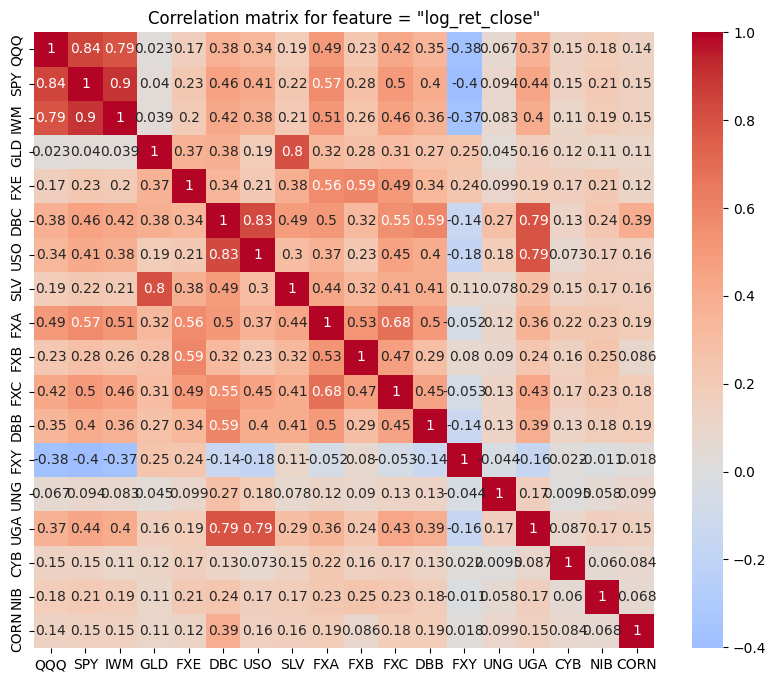

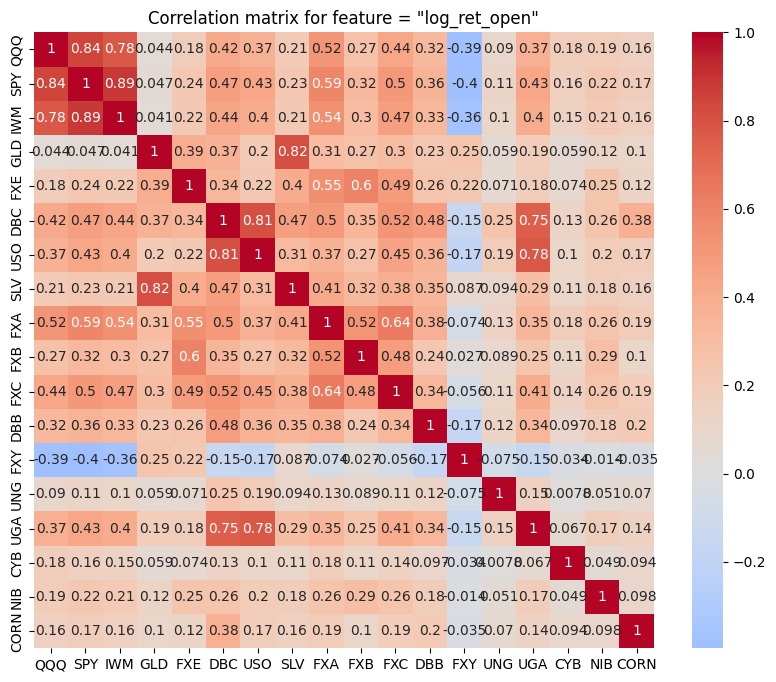

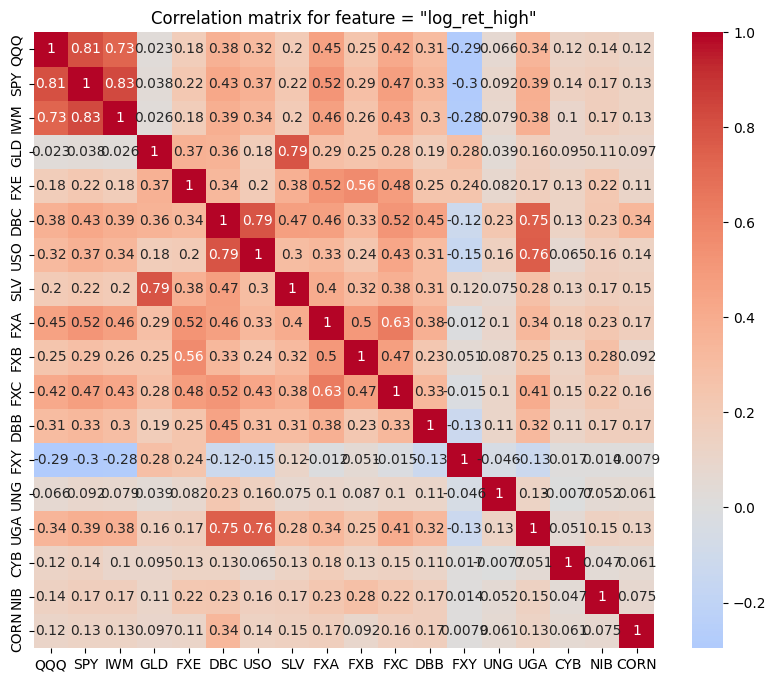

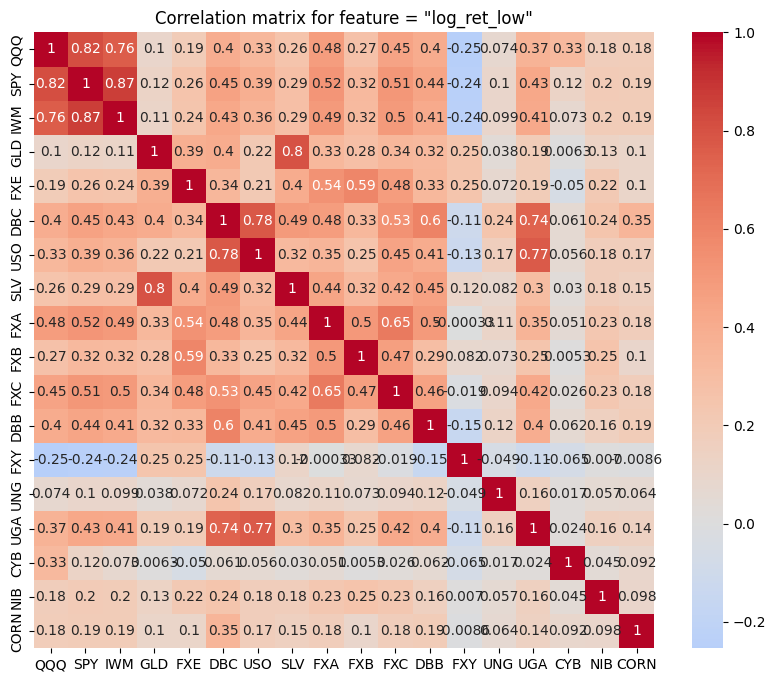

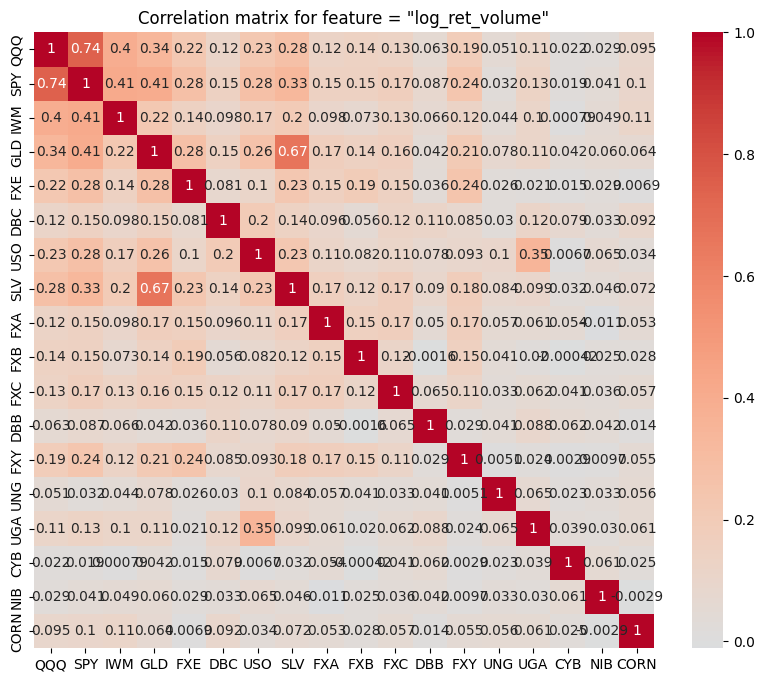

In [3]:
data_path = "../../../datasets/stock_data/merged_future_etfs_stock_data.csv"
macro_data_path = "../../../datasets/macro_processed/macro_data_resampled.csv"
output_path_folder = "../../../datasets/output_data_lambert_future_etfs/"
max_seq_len = 120

# ETF Lambert GAN preprocessing.
# Inputs are produced by data_preparation_etf.ipynb:
#   - merged_future_etfs_stock_data.csv
#   - macro_data_resampled.csv
# Keep log_returns to stay in line with the current WaveNet training/inversion path.
feature_method = "log_returns"  # "derived" or "log_returns"

for required_path in [data_path, macro_data_path]:
    if not os.path.exists(required_path):
        raise FileNotFoundError(f"Missing {required_path}. Run data_preparation_etf.ipynb first.")

(output_data, output_macro_data, output_history_data, output_mask_data,
 output_starting_date, time, max_seq_len, ticker_list,
 output_orginal_open, output_orginal_close, output_adj_factor,
 lambert_fit_params, log_returns_initials) = data_preprocess(
    file_name=data_path,
    macro_file_name=macro_data_path,
    max_seq_len=max_seq_len,
    normalization_method="lambert",
    feature_method=feature_method,
)

import numpy as np
print("X shape:", output_data.shape)
print("History shape:", output_history_data.shape)
print("Macro shape:", output_macro_data.shape)

# create the output folder if not exist
if not os.path.exists(output_path_folder):
    os.makedirs(output_path_folder)

# save the data to npy file
np.save(output_path_folder+"output_data.npy", output_data)
np.save(output_path_folder+"output_history_data.npy", output_history_data)
np.save(output_path_folder+"output_macro_data.npy", output_macro_data)
np.save(output_path_folder+"output_mask_data.npy", output_mask_data)
np.save(output_path_folder+"output_starting_date.npy", output_starting_date)
np.save(output_path_folder+"time.npy", time)
np.save(output_path_folder+"ticker_list.npy", ticker_list)
np.save(output_path_folder+"max_seq_len.npy", max_seq_len)
np.save(output_path_folder+"output_original_open.npy", output_orginal_open)
np.save(output_path_folder+"output_original_close.npy", output_orginal_close)
np.save(output_path_folder+"output_adj_factor.npy", output_adj_factor)

import pickle
if lambert_fit_params:
    with open(output_path_folder+"lambert_fit_params.pkl", "wb") as f:
        pickle.dump(lambert_fit_params, f)
if log_returns_initials:
    for key, val in log_returns_initials.items():
        np.save(output_path_folder+f"output_initial_{key}.npy", val)

Loaded output_data (2553, 120, 90) with 18 tickers
channel                             mean      std     skew     kurt     p0.1    p99.9   max|x|   %|x|>4
log_ret_close                    -0.0040   0.8731  -0.0694  -0.0751   -2.707    2.580    2.892    0.00%
log_ret_open                     -0.0041   0.8690  -0.0754  -0.1170   -2.693    2.609    3.420    0.00%
log_ret_high                     -0.0046   0.9043  -0.0378  -0.1797   -2.732    2.592    3.138    0.00%
log_ret_low                       0.0015   0.8930  -0.1104  -0.2127   -2.737    2.519    3.789    0.00%
log_ret_volume                   -0.0052   1.1353   0.0868  -0.7049   -2.695    2.844    3.101    0.00%


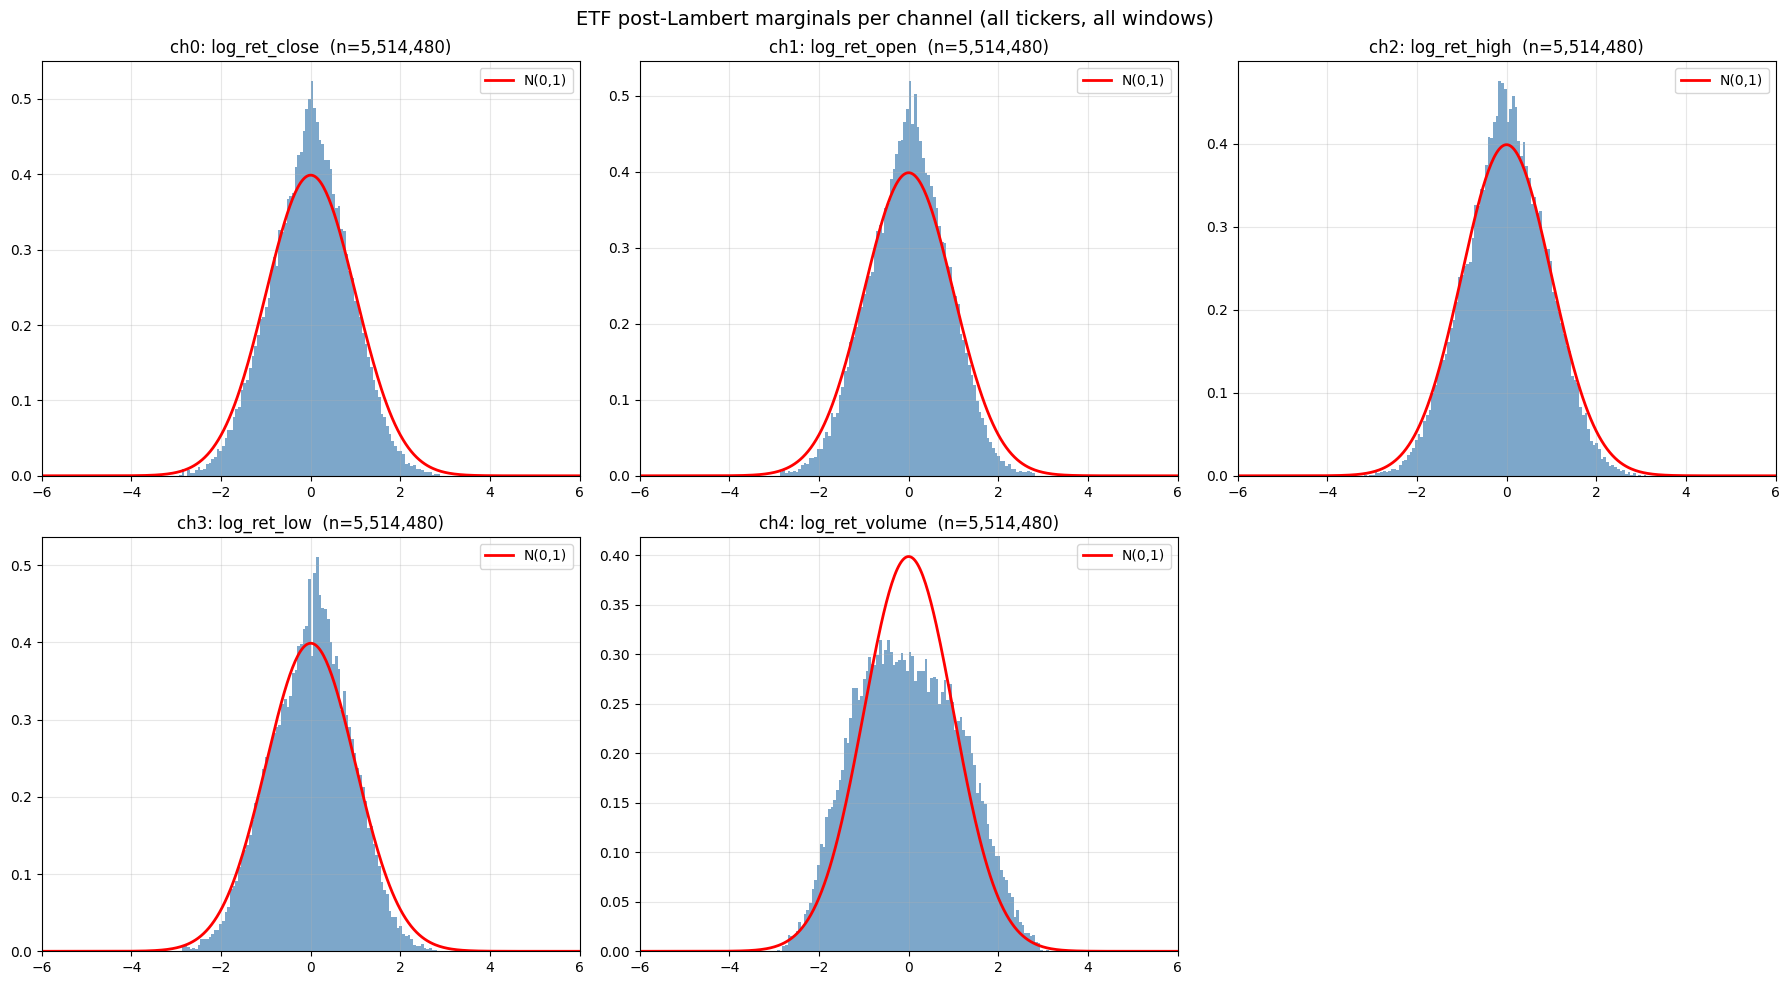


Health check:
  - mean ~0, std ~1
  - |skew| < 0.5 where possible
  - |excess kurt| < 1 (heavy tails remain if > 2)
  - %|x|>4 should be tiny (N(0,1) expects ~0.006%)


In [4]:
# ============================================================
# Post-Lambert marginal histograms per channel
# ------------------------------------------------------------
# Loads the just-saved ETF output_data.npy so it works regardless
# of kernel state (can be re-run without re-preprocessing).
# If Lambert did its job, each of the 5 log-return channels should
# look approximately N(0, 1):
#   - mean ~ 0, std ~ 1
#   - |skew| small where possible
#   - no density spike at 0
#   - no fat tails past ~+/-4 (N(0,1) puts ~0.006% mass beyond)
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

preprossed_data_folder = "../../../datasets/output_data_lambert_future_etfs"
output_data = np.load(f"{preprossed_data_folder}/output_data.npy")
ticker_list = list(np.load(f"{preprossed_data_folder}/ticker_list.npy"))

CHANNEL_NAMES = ['log_ret_close', 'log_ret_open',
                 'log_ret_high', 'log_ret_low',
                 'log_ret_volume']
n_tickers = len(ticker_list)
print(f"Loaded output_data {output_data.shape} with {n_tickers} tickers")

# output_data: (W, T, 5*n_tickers). Channel c of ticker t at col t*5 + c.
per_channel = []
for c in range(5):
    cols = [t * 5 + c for t in range(n_tickers)]
    arr = output_data[:, :, cols].reshape(-1)
    per_channel.append(arr)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

print(f"{'channel':<30s}  {'mean':>8s} {'std':>8s} {'skew':>8s} {'kurt':>8s} "
      f"{'p0.1':>8s} {'p99.9':>8s} {'max|x|':>8s} {'%|x|>4':>8s}")
for c in range(5):
    x = per_channel[c]
    x = x[np.isfinite(x)]
    ax = axes[c]
    ax.hist(x, bins=200, density=True, alpha=0.7, color='steelblue',
            range=(-6, 6))
    xx = np.linspace(-6, 6, 400)
    ax.plot(xx, stats.norm.pdf(xx), 'r-', lw=2, label='N(0,1)')
    ax.set_title(f'ch{c}: {CHANNEL_NAMES[c]}  (n={len(x):,})')
    ax.set_xlim(-6, 6)
    ax.legend()
    ax.grid(alpha=0.3)
    print(f"{CHANNEL_NAMES[c]:<30s}  "
          f"{x.mean():>8.4f} {x.std():>8.4f} "
          f"{stats.skew(x):>8.4f} {stats.kurtosis(x):>8.4f} "
          f"{np.quantile(x, 0.001):>8.3f} {np.quantile(x, 0.999):>8.3f} "
          f"{np.abs(x).max():>8.3f} {(np.abs(x) > 4).mean() * 100:>7.2f}%")

axes[5].axis('off')
plt.suptitle('ETF post-Lambert marginals per channel (all tickers, all windows)',
             fontsize=14)
plt.tight_layout()
plt.savefig('./lambert_marginals_future_etfs.png', dpi=100, bbox_inches='tight')
plt.show()

print("\nHealth check:")
print("  - mean ~0, std ~1")
print("  - |skew| < 0.5 where possible")
print("  - |excess kurt| < 1 (heavy tails remain if > 2)")
print("  - %|x|>4 should be tiny (N(0,1) expects ~0.006%)")

In [5]:
import numpy as np
preprossed_data_folder="../../../datasets/output_data_lambert_future_etfs"
# instead of processing the data each time, read the prossesed data from npy file

output_data = np.load(f"{preprossed_data_folder}/output_data.npy")
output_macro_data = np.load(f"{preprossed_data_folder}/output_macro_data.npy")
output_history_data = np.load(f"{preprossed_data_folder}/output_history_data.npy")
T = np.load(f"{preprossed_data_folder}/time.npy")
bbid_list = np.load(f"{preprossed_data_folder}/ticker_list.npy")
output_mask_data = np.load(f"{preprossed_data_folder}/output_mask_data.npy")
output_starting_date = np.load(f"{preprossed_data_folder}/output_starting_date.npy",allow_pickle=True)
max_seq_len = np.load(f"{preprossed_data_folder}/max_seq_len.npy")
output_orginal_open = np.load(f"{preprossed_data_folder}/output_original_open.npy")
output_orginal_close = np.load(f"{preprossed_data_folder}/output_original_close.npy")
import pandas as pd

# print the shape of the data
print("output_data shape:", output_data.shape)
print("output_macro_data shape:", output_macro_data.shape)
print("output_history_data shape:", output_history_data.shape)
print("output_mask_data shape:", output_mask_data.shape)

output_data_flat = output_data.reshape(-1, output_data.shape[-1])  # Flatten along the first two dimensions
output_mask_data_flat = output_mask_data.reshape(-1, output_mask_data.shape[-1])
output_macro_data_flat = output_macro_data.reshape(-1, output_macro_data.shape[-1])
output_history_data_flat = output_history_data.reshape(-1, output_history_data.shape[-1])
output_orginal_open_flat = output_orginal_open.flatten()
output_orginal_close_flat = output_orginal_close.flatten()

print(f"output_data: {pd.DataFrame(output_data_flat).describe()}")
print(f"output_mask_data: {pd.DataFrame(output_mask_data_flat).describe()}")
print(f"output_macro_data: {pd.DataFrame(output_macro_data_flat).describe()}")
print(f"output_history_data: {pd.DataFrame(output_history_data_flat).describe()}")
print(f"output_orginal_open: {pd.DataFrame(output_orginal_open_flat).describe()}")
print(f"output_orginal_close: {pd.DataFrame(output_orginal_close_flat).describe()}")

# print preview of the data
print("output_data: ", output_data_flat[:10])
print("output_mask_data: ", output_mask_data_flat[:10])
print("output_macro_data: ", output_macro_data_flat[:10])
print("output_history_data: ", output_history_data_flat[:10])
print("output_orginal_open: ", output_orginal_open_flat[:10])
print("output_orginal_close: ", output_orginal_close_flat[:10])

output_data shape: (2553, 120, 90)
output_macro_data shape: (2553, 120, 46)
output_history_data shape: (2553, 120, 90)
output_mask_data shape: (2553, 120, 90)
output_data:                   0              1              2              3   \
count  306360.000000  306360.000000  306360.000000  306360.000000   
mean        0.037282       0.036428       0.043199       0.046941   
std         0.817897       0.814198       0.817173       0.840975   
min        -2.759196      -2.796585      -2.499374      -2.764814   
25%        -0.430703      -0.481645      -0.447511      -0.517311   
50%         0.075964       0.101161       0.084255       0.107541   
75%         0.593825       0.589108       0.597527       0.630630   
max         2.643376       2.601699       2.493168       2.766220   

                  4              5              6              7   \
count  306360.000000  306360.000000  306360.000000  306360.000000   
mean       -0.002098       0.029769       0.032076       0.035018   

In [6]:
# Quick sanity check summary
import os
print("=== Output Summary ===")
print(f"output_data shape: {output_data.shape}")
print(f"output_macro_data shape: {output_macro_data.shape}")
print(f"output_history_data shape: {output_history_data.shape}")
print(f"output_mask_data shape: {output_mask_data.shape}")
print(f"output_starting_date shape: {output_starting_date.shape}")
print(f"output_orginal_open shape: {output_orginal_open.shape}")
print(f"output_orginal_close shape: {output_orginal_close.shape}")
print(f"ticker_list ({len(bbid_list)}): {list(bbid_list)}")
print(f"max_seq_len: {max_seq_len}")
print(f"time len: {len(T)}")

# Check for NaN/Inf
print(f"\noutput_data NaN: {np.isnan(output_data).sum()}, Inf: {np.isinf(output_data).sum()}")
print(f"output_macro_data NaN: {np.isnan(output_macro_data).sum()}, Inf: {np.isinf(output_macro_data).sum()}")
print(f"output_history_data NaN: {np.isnan(output_history_data).sum()}, Inf: {np.isinf(output_history_data).sum()}")

# Data ranges
print(f"\noutput_data range: [{output_data.min():.4f}, {output_data.max():.4f}], mean={output_data.mean():.4f}, std={output_data.std():.4f}")
print(f"output_macro_data range: [{output_macro_data.min():.4f}, {output_macro_data.max():.4f}]")
print(f"output_history_data range: [{output_history_data.min():.4f}, {output_history_data.max():.4f}]")

# Check saved files
lambert_dir = "../../../datasets/output_data_lambert_future_etfs/"
if os.path.exists(lambert_dir):
    files = sorted(os.listdir(lambert_dir))
    print(f"\nSaved files in output_data_lambert_future_etfs/ ({len(files)}):")
    for f in files:
        fpath = os.path.join(lambert_dir, f)
        size_mb = os.path.getsize(fpath) / (1024*1024)
        print(f"  {f}: {size_mb:.2f} MB")

=== Output Summary ===
output_data shape: (2553, 120, 90)
output_macro_data shape: (2553, 120, 46)
output_history_data shape: (2553, 120, 90)
output_mask_data shape: (2553, 120, 90)
output_starting_date shape: (2553, 18)
output_orginal_open shape: (2553, 18)
output_orginal_close shape: (2553, 18, 120)
ticker_list (18): [np.str_('QQQ'), np.str_('SPY'), np.str_('IWM'), np.str_('GLD'), np.str_('FXE'), np.str_('DBC'), np.str_('USO'), np.str_('SLV'), np.str_('FXA'), np.str_('FXB'), np.str_('FXC'), np.str_('DBB'), np.str_('FXY'), np.str_('UNG'), np.str_('UGA'), np.str_('CYB'), np.str_('NIB'), np.str_('CORN')]
max_seq_len: 120
time len: 2553

output_data NaN: 0, Inf: 0
output_macro_data NaN: 0, Inf: 0
output_history_data NaN: 0, Inf: 0

output_data range: [-3.7058, 3.7891], mean=-0.0033, std=0.9404
output_macro_data range: [0.0000, 1.0000]
output_history_data range: [-3.7058, 3.7891]

Saved files in output_data_lambert_future_etfs/ (15):
  lambert_fit_params.pkl: 0.05 MB
  max_seq_len.npy: 0.